# 3W Dataset: Transfer Learning

We measure how well classifiers transfer across domains in the 3W dataset.
Cross-source (simulated/hand-drawn/real), mixed-source, and intra-real transfer
between different wells and time periods.

## 1. Setup and data loading

We load the 3W dataset from the extracted CSVs (one directory per event class, instances split by source) and define the shared configuration: class names, variable names, and the 56-dim statistical feature space used by every experiment.

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
}
VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP',
                  'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
SOURCES = ['real', 'simulated', 'handdrawn']


In [3]:
def detect_source(filename: str) -> str:
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'):   return 'handdrawn'
    if name.startswith('SIMULATED'): return 'simulated'
    if name.startswith('WELL'):    return 'real'
    return 'unknown'

def load_all_instances(data_dir: str, class_names: list) -> dict:
    all_instances = {}
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            df = pd.read_csv(fpath)
            if 'timestamp' in df.columns:
                df['timestamp'] = pd.to_datetime(df['timestamp'])
            instance_id = os.path.splitext(fname)[0]
            if source not in class_instances:
                class_instances[source] = []
            class_instances[source].append({
                'id': instance_id, 'path': fpath, 'data': df,
                'n_vars': len([c for c in df.columns if c not in ('timestamp', 'class')]),
                'n_obs': df.shape[0],
            })
        if class_instances:
            all_instances[class_code] = class_instances
    return all_instances

data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total = sum(sum(len(lst) for lst in src_dict.values()) for src_dict in data.values())
print(f'Loaded {total} instances across {len(data)} classes.')

Loaded 1984 instances across 9 classes.


In [4]:
source_pairs = [('real', 'simulated'), ('real', 'handdrawn'), ('simulated', 'handdrawn')]

def get_viable_classes(data, s1, s2, min_instances=3):
    """Return classes where both sources have >= min_instances instances."""
    return [cls for cls in sorted(data.keys())
            if s1 in data[cls] and s2 in data[cls]
            and len(data[cls][s1]) >= min_instances
            and len(data[cls][s2]) >= min_instances]


## 2. Transfer learning performance drop

We will measure how much classifier performance drops when a model trained on one source is evaluated on another. We train a Random Forest on the source instances and test it on the target instances, comparing multi-class and per-class binary F1 across three scenarios: Real to Real (ceiling), Simulated to Real, and Hand-drawn to Real.

In [5]:
def extract_features(data: dict, source: str, classes: list) -> tuple:
    """
    Extract statistical features per instance.
    Returns (X, y) where X is (n_instances, n_features) and y is class labels.

    Args:
        data (dict): The dataset dictionary.
        source (str): The source from which to extract features.
        classes (list): List of class codes to include in the feature extraction.
    Returns:
        tuple: (X, y, instance_ids) where X is the feature matrix, y is the array of class labels, and instance_ids is a list of instance identifiers.
    """
    features = []
    labels = []
    instance_ids = []
    
    for cls in classes:
        if cls not in data or source not in data[cls]:
            continue
        for inst in data[cls][source]:
            df = inst['data']
            feats = []
            for var in VARIABLE_NAMES:
                if var in df.columns:
                    vals = df[var].values
                    feats.extend([
                        np.nanmean(vals),
                        np.nanstd(vals),
                        np.nanmin(vals),
                        np.nanpercentile(vals, 25),
                        np.nanpercentile(vals, 50),
                        np.nanpercentile(vals, 75),
                        np.nanmax(vals),
                    ])
                else:
                    feats.extend([np.nan] * 7)
            
            features.append(feats)
            labels.append(cls)
            instance_ids.append(inst['id'])
    
    X = np.array(features, dtype=np.float64)
    y = np.array(labels)
    
    # nan values are replaced with column medians (or 0 if entire column is NaN)
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    for j in range(X.shape[1]):
        if np.isnan(col_medians[j]):
            col_medians[j] = 0.0
        X[nan_mask[:, j], j] = col_medians[j]
    
    # replace inf values with column max/min (or 1/-1 if entire column is inf)
    for j in range(X.shape[1]):
        col = X[:, j]
        finite_vals = col[np.isfinite(col)]
        if len(finite_vals) > 0:
            col_max = np.max(finite_vals)
            col_min = np.min(finite_vals)
        else:
            col_max, col_min = 1.0, -1.0
        col[~np.isfinite(col) & (col > 0)] = col_max
        col[~np.isfinite(col) & (col < 0)] = col_min
        # clipping to avoid extreme values
        X[:, j] = np.clip(col, -1e15, 1e15)
    
    return X, y, instance_ids

stat_names = ['mean', 'std', 'min', 'p25', 'p50', 'p75', 'max']
feature_names = [f'{var}_{stat}' for var in VARIABLE_NAMES for stat in stat_names]
print(f'Feature vector: {len(feature_names)} dimensions')

Feature vector: 56 dimensions


In [6]:
def evaluate_transfer(data: dict, source: str, target: str, classes: list, n_trees: int = 100) -> dict | None:
    """
    Train on source, evaluate on target (and source for baseline).
    Performs multi-class classification on the given classes. Requires at least
    2 classes for meaningful evaluation.

    Args:
        data (dict): The dataset dictionary.
        source (str): The source domain to train on.
        target (str): The target domain to evaluate on.
        classes (list): List of class codes to include in the evaluation.
        n_trees (int): Number of trees for the Random Forest classifier.
    Returns:
        dict | None: Dictionary containing F1 scores and other metrics, or None if evaluation is not feasible due to insufficient data or classes.
    """
    X_src, y_src, _ = extract_features(data, source, classes)
    X_tgt, y_tgt, _ = extract_features(data, target, classes)
    
    if len(X_src) < 10 or len(X_tgt) < 5:
        return None
    if len(np.unique(y_src)) < 2 or len(np.unique(y_tgt)) < 2:
        return None
    
    if source == target:
        from sklearn.model_selection import train_test_split
        X_src, X_tgt, y_src, y_tgt = train_test_split(
            X_src, y_src, test_size=0.3, stratify=y_src, random_state=42)
    
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42, n_jobs=-1)
    
    # source to source: cross-validation to get baseline F1
    min_class_count = min(np.bincount(y_src))
    n_splits = max(2, min(5, min_class_count))
    try:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        y_pred_cv = cross_val_predict(rf, X_src, y_src, cv=skf)
        f1_src = f1_score(y_src, y_pred_cv, average='macro')
    except Exception:
        # fallback to a simple train/test split if cv fails
        from sklearn.model_selection import train_test_split
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_src, y_src, test_size=0.3, stratify=y_src, random_state=42)
        rf.fit(X_tr, y_tr)
        f1_src = f1_score(y_te, rf.predict(X_te), average='macro')
    
    # source to target: train on all source, predict on target
    rf.fit(X_src, y_src)
    y_pred_tgt = rf.predict(X_tgt)
    f1_tgt = f1_score(y_tgt, y_pred_tgt, average='macro')
    acc_tgt = accuracy_score(y_tgt, y_pred_tgt)
    
    f1_drop = f1_src - f1_tgt
    
    return {
        'F1_source': f1_src,
        'F1_target': f1_tgt,
        'F1_drop': f1_drop,
        'accuracy_target': acc_tgt,
        'n_source': len(X_src),
        'n_target': len(X_tgt),
        'n_classes': len(np.unique(y_src)),
    }

transfer_scenarios = [
    ('real', 'real', 'Real → Real'),
    ('simulated', 'real', 'Simulated → Real'),
    ('handdrawn', 'real', 'Hand-drawn → Real'),
]

tl_results = []
for source, target, desc in transfer_scenarios:
    all_classes = get_viable_classes(data, source, target, min_instances=3)
    
    if len(all_classes) >= 2:
        result = evaluate_transfer(data, source, target, all_classes)
        if result:
            result['source'] = source
            result['target'] = target
            result['scenario'] = desc
            result['num_classes'] = len(all_classes)
            result['classes'] = ', '.join(str(c) for c in all_classes)
            tl_results.append(result)
    
    # evaluation per-class: leave-one-class-out within the source domain
    for cls in all_classes:
        other_classes = [c for c in all_classes if c != cls]
        if len(other_classes) >= 1:
            pair = [cls, other_classes[0]]  # binary: cls vs nearest other
            result = evaluate_transfer(data, source, target, pair)
            if result:
                result['source'] = source
                result['target'] = target
                result['scenario'] = desc
                result['class'] = cls
                result['event'] = CLASS_NAMES[cls][:25]
                tl_results.append(result)

tl_df = pd.DataFrame(tl_results)

multi_class = tl_df[~tl_df['class'].notna()] if 'class' in tl_df.columns else tl_df
if len(multi_class) > 0:
    print('\nMulti-class transfer')
    display(multi_class[['scenario', 'classes', 'num_classes', 'F1_source', 'F1_target',
                         'F1_drop', 'n_source', 'n_target']])

per_class = tl_df[tl_df['class'].notna()].copy() if 'class' in tl_df.columns else pd.DataFrame()
if len(per_class) > 0:
    print(f'\nPer-class binary transfer ({len(per_class)} results)')
    display(per_class[['scenario', 'class', 'event', 'F1_source', 'F1_target', 'F1_drop',
                       'n_source', 'n_target']].sort_values('F1_drop', ascending=False))



Multi-class transfer


,scenario,classes,num_classes,F1_source,F1_target,F1_drop,n_source,n_target
0,Real → Real,"0, 1, 2, 3, 4, 5, 6, 7, 8",9.0,0.606851,0.739258,-0.132407,717,308
10,Simulated → Real,"1, 2, 3, 5, 6, 8",6.0,0.983987,0.070902,0.913085,939,80
17,Hand-drawn → Real,"1, 7",2.0,0.900000,0.649351,0.250649,20,9



Per-class binary transfer (17 results)


,scenario,class,event,F1_source,F1_target,F1_drop,n_source,n_target
14,Simulated → Real,5.0,Rapid Productivity Loss,1.000000,0.000000,1.000000,553,17
13,Simulated → Real,3.0,Severe Slugging,0.988803,0.026316,0.962487,188,37
11,Simulated → Real,1.0,Abrupt Increase of BSW,1.000000,0.370370,0.629630,130,27
12,Simulated → Real,2.0,Spurious Closure of DHSV,1.000000,0.441379,0.558621,130,27
9,Real → Real,8.0,Hydrate in Production Lin,0.832736,0.498607,0.334129,420,180
19,Hand-drawn → Real,7.0,Scaling in PCK,0.949875,0.649351,0.300524,20,9
18,Hand-drawn → Real,1.0,Abrupt Increase of BSW,0.900000,0.649351,0.250649,20,9
7,Real → Real,6.0,Quick Restriction in PCK,0.698212,0.497222,0.200990,422,181
15,Simulated → Real,6.0,Quick Restriction in PCK,0.993316,0.803571,0.189744,329,11
16,Simulated → Real,8.0,Hydrate in Production Lin,1.000000,0.854545,0.145455,195,8


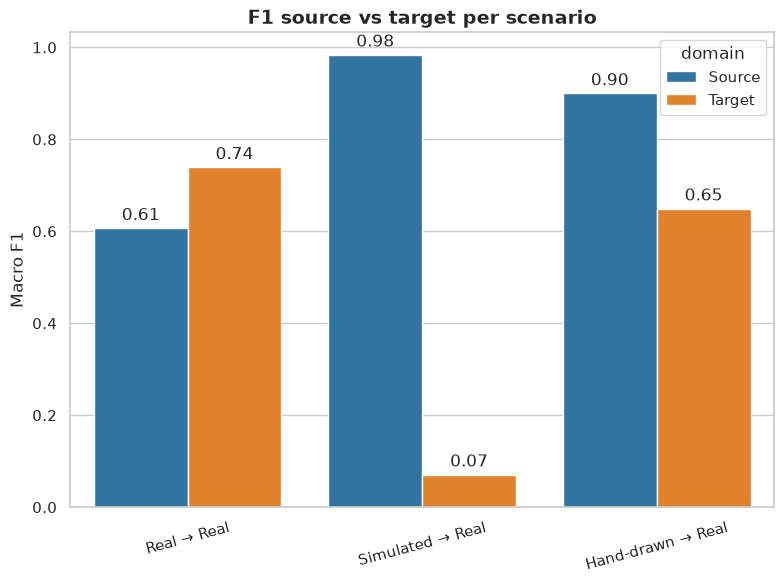

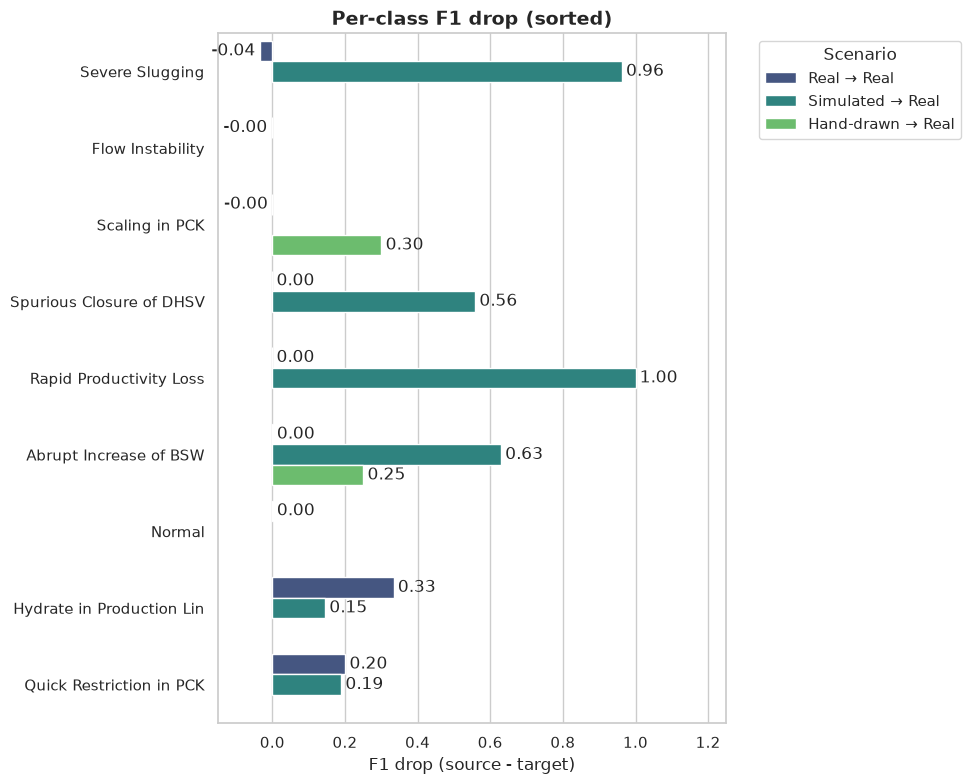

In [ ]:
multi_long = multi_class.melt(
    id_vars='scenario',
    value_vars=['F1_source', 'F1_target'],
    var_name='domain', 
    value_name='F1'
)
multi_long['domain'] = multi_long['domain'].str.replace('F1_', '').str.capitalize()

per_class_sorted = per_class.sort_values('F1_drop')


fig1, ax1 = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=multi_long, 
    x='scenario', 
    y='F1', 
    hue='domain', 
    palette=['#1f77b4', '#ff7f0e'], 
    ax=ax1
)

ax1.set(title='F1 source vs target per scenario', ylabel='Macro F1', xlabel='')
ax1.set_title('F1 source vs target per scenario', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()


fig2, ax2 = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=per_class_sorted, 
    y='event', 
    x='F1_drop', 
    hue='scenario', 
    palette='viridis',
    ax=ax2
)

ax2.set(title='Per-class F1 drop', ylabel='', xlabel='F1 drop (source - target)', xlim=(-0.15, 1.25))
ax2.set_title('Per-class F1 drop', fontsize=14, fontweight='bold')
ax2.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

The bars confirm the transfer hierarchy of this section:

1. **Simulated to Real**: F1 collapses from 0.98 (within-source CV) to 0.07 on real data.
2. **Hand-drawn to Real**: F1 drops from 0.90 to 0.65, a moderate degradation that is still 3.6x better than the physics simulator.
3. **Real to Real**: the ceiling, at 0.61 CV baseline against a 0.74 target F1.

The per-class panel shows that the simulated-to-real collapse is driven by classes 5 (Rapid Productivity Loss) and 3 (Severe Slugging), which lose almost all predictive power, while classes 6 and 8 degrade only mildly.

## 3. Mixed-source transfer

We will test whether adding synthetic data to the real training split helps or hurts the real test F1.

This section uses the same fixed instance-level stratified 70/30 split (seed 42) and
train-only feature imputation as stage 3 (`stage3-synthetic_generation/
3w_cvae_augmentation.ipynb`), and includes all 9 real classes. 
Classes 0, 4 and 7 have no simulated counterpart and are never
mixed.


In [8]:
from sklearn.model_selection import train_test_split

# Shared fixed split: identical to stage 3 (3w_cvae_augmentation.ipynb):
# instance-level stratified 70/30, seed 42, split BEFORE feature extraction so
# imputation medians are train-only.
real_by_class = {c: list(data[c]['real']) for c in sorted(CLASS_NAMES) if 'real' in data.get(c, {})}
all_insts, y_all = [], []
for c in sorted(real_by_class):
    all_insts.extend(real_by_class[c])
    y_all.extend([c] * len(real_by_class[c]))

tr_idx, te_idx, _, _ = train_test_split(
    np.arange(len(all_insts)), y_all, test_size=0.3, stratify=y_all, random_state=42)

def build_dict(idx):
    d = {}
    for i in idx:
        inst, c = all_insts[i], y_all[i]
        d.setdefault(c, {'real': []})['real'].append(inst)
    return d

data_train = build_dict(tr_idx)
data_test = build_dict(te_idx)
X_train, y_train, _ = extract_features(data_train, 'real', sorted(CLASS_NAMES))
X_test, y_test, _ = extract_features(data_test, 'real', sorted(CLASS_NAMES))
print(f'Real train: {X_train.shape[0]} instances, test: {X_test.shape[0]} instances')


Real train: 717 instances, test: 308 instances


In [9]:
def evaluate_mixed_fixed(X_tr, y_tr, X_te, y_te, mix_sets, n_seeds=10, n_trees=100):
    """Fixed-split mixed-source evaluation (same protocol as stage 3).

    Args:
        X_tr, y_tr: real training features/labels (shared fixed split).
        X_te, y_te: real test features/labels (shared fixed split).
        mix_sets: dict label mapping to (X, y) of synthetic instances appended to the
                  real training split.
        n_seeds: RF seeds 42..42+n_seeds-1 (same as stage 3).
    Returns:
        dict label mapping to (macro-F1 mean, std) over the n_seeds runs.
    """
    def run(X, y):
        macro = []
        for k in range(n_seeds):
            rf = RandomForestClassifier(n_estimators=n_trees, random_state=42 + k, n_jobs=-1)
            rf.fit(X, y)
            macro.append(f1_score(y_te, rf.predict(X_te), average='macro'))
        return float(np.mean(macro)), float(np.std(macro))

    results = {'Real only': run(X_tr, y_tr)}
    for label, (X_mix, y_mix) in mix_sets.items():
        results[label] = run(np.vstack([X_tr, X_mix]), np.concatenate([y_tr, y_mix]))
    return results

mix_sets = {}

X_sim, y_sim, _ = extract_features(data, 'simulated', sorted(CLASS_NAMES))
mix_sets['Real + Simulated (939)'] = (X_sim, y_sim)

X_hd, y_hd, _ = extract_features(data, 'handdrawn', sorted(CLASS_NAMES))
mix_sets['Real + Hand-drawn (20)'] = (X_hd, y_hd)

print('Mix sets:', {k: (v[0].shape[0], v[0].shape[1]) for k, v in mix_sets.items()})


Mix sets: {'Real + Simulated (939)': (939, 56), 'Real + Hand-drawn (20)': (20, 56)}


In [10]:
mixed_results = evaluate_mixed_fixed(X_train, y_train, X_test, y_test, mix_sets)

base_m, base_s = mixed_results['Real only']
rows = []
for label, (m, s) in mixed_results.items():
    rows.append({'config': label, 'macro-F1': f'{m:.3f} +/- {s:.3f}',
                 'delta vs real-only': f'{m - base_m:+.3f}'})
mixed_df = pd.DataFrame(rows)
display(mixed_df)

# Per-class one-vs-rest F1 on the rare classes (the classes that need the most help)
rare = [1, 5, 6, 7, 8]
configs = [('Real only', (X_train, y_train))]
configs += [(label, (np.vstack([X_train, X_mix]), np.concatenate([y_train, y_mix])))
            for label, (X_mix, y_mix) in mix_sets.items()]
for label, (X, y) in configs:
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    y_pred = rf.predict(X_test)
    per = {c: f1_score(y_test == c, y_pred == c) for c in rare}
    print(f'{label:24s} rare-class F1: ' + ', '.join(f'c{c}: {v:.2f}' for c, v in per.items()))


,config,macro-F1,delta vs real-only
0,Real only,0.741 +/- 0.001,+0.000
1,Real + Simulated (939),0.740 +/- 0.002,-0.001
2,Real + Hand-drawn (20),0.740 +/- 0.001,-0.000


Real only                rare-class F1: c1: 0.00, c5: 0.86, c6: 1.00, c7: 0.00, c8: 1.00
Real + Simulated (939)   rare-class F1: c1: 0.00, c5: 0.86, c6: 1.00, c7: 0.00, c8: 1.00
Real + Hand-drawn (20)   rare-class F1: c1: 0.00, c5: 0.86, c6: 1.00, c7: 0.00, c8: 1.00


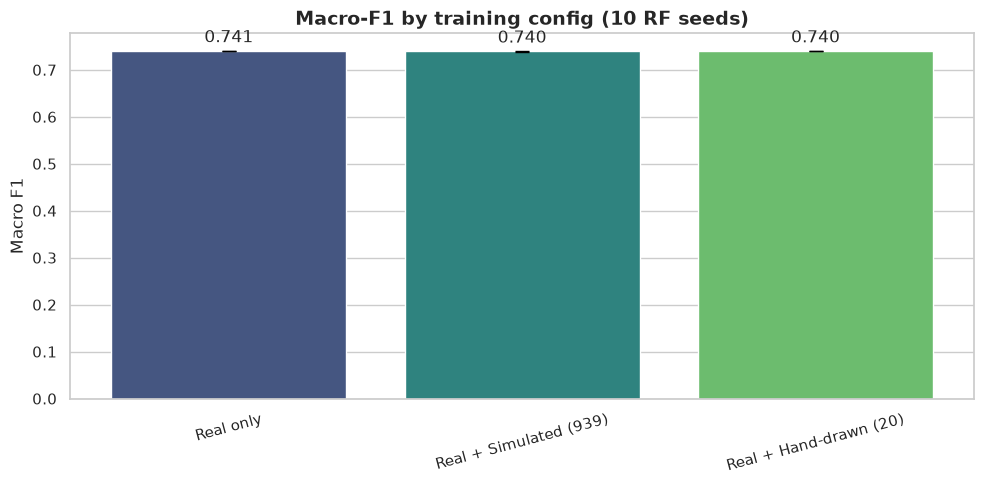

In [11]:
# Figure: macro-F1 per training config (10 RF seeds), mean +/- std
labels = list(mixed_results)
means = [mixed_results[k][0] for k in labels]
stds = [mixed_results[k][1] for k in labels]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=labels, y=means, hue=labels, palette='viridis', legend=False, ax=ax)
ax.errorbar(x=range(len(labels)), y=means, yerr=stds,
            fmt='none', color='black', capsize=5)
for i, v in enumerate(means):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
ax.set_title('Macro-F1 by training config (10 RF seeds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Macro F1')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

The three configs are statistically indistinguishable: **Real + Simulated (939)** and **Real + Hand-drawn (20)** move macro-F1 by less than 0.001 against **Real only**, with overlapping seed standard deviations. The rare classes stay flat as well (classes 6 and 8 at 1.00, class 5 at 0.86, classes 1 and 7 at 0.00). Adding synthetic data does not help: quantity does not compensate for quality.

## 4. Intra-real splits: Well-to-well transfer

We will train on one set of wells and test on another, for the same event types, to measure how much well variation alone degrades transfer. Class 0 compares wells 1+2 vs 5+6, class 4 compares wells 1+2 vs 5+10.

In [12]:
def get_well_id(inst_id):
    if inst_id.startswith('WELL'): return inst_id.split('_')[0]
    return None

source_wells = ['WELL-00001', 'WELL-00002']
target_wells = ['WELL-00005', 'WELL-00006']

data_well = {}
for cls in sorted(data.keys()):
    data_well[cls] = {}
    src = [inst for inst in data[cls].get('real', []) if get_well_id(inst['id']) in source_wells]
    tgt = [inst for inst in data[cls].get('real', []) if get_well_id(inst['id']) in target_wells]
    if src: data_well[cls]['well_source'] = src
    if tgt: data_well[cls]['well_target'] = tgt

print('Well-based split instances per label:')
if 4 in data_well and 'well_source' in data_well[4] and 'well_target' in data_well[4]:
    print(f'\tClass 4 - well_source: {len(data_well[4]["well_source"])}')
    print(f'\tClass 4 - well_target: {len(data_well[4]["well_target"])}')
for k in ['well_source', 'well_target']:
    for c in sorted(data_well.keys()):
        if k in data_well[c]:
            print(f'\tClass {c} - {k}: {len(data_well[c][k])}')

Well-based split instances per label:
	Class 4 - well_source: 149
	Class 4 - well_target: 38
	Class 0 - well_source: 304
	Class 1 - well_source: 2
	Class 2 - well_source: 1
	Class 3 - well_source: 1
	Class 4 - well_source: 149
	Class 6 - well_source: 3
	Class 7 - well_source: 1
	Class 0 - well_target: 196
	Class 1 - well_target: 3
	Class 4 - well_target: 38
	Class 7 - well_target: 2


In [13]:
c4_src_wells = ['WELL-00001', 'WELL-00002']
c4_tgt_wells = ['WELL-00005', 'WELL-00010']

data_well_c4 = {}
for cls in [4]:
    data_well_c4[cls] = {}
    if cls in data and 'real' in data[cls]:
        data_well_c4[cls]['source'] = [inst for inst in data[cls]['real'] if get_well_id(inst['id']) in c4_src_wells]
        data_well_c4[cls]['target'] = [inst for inst in data[cls]['real'] if get_well_id(inst['id']) in c4_tgt_wells]

print('Class 4 (Flow instability) well split:')
print(f'\tSource wells 1+2: {len(data_well_c4[4]["source"])} instances')
print(f'\tTarget wells 5+10: {len(data_well_c4[4]["target"])} instances')

def collect_well_obs_c4(dw, wk, var):
    vals = []
    if 4 in dw and wk in dw[4]:
        for inst in dw[4][wk]:
            if var in inst['data'].columns:
                col = inst['data'][var].dropna().values[:20000]
                if len(col) > 0: vals.extend(col)
    return np.array(vals)

print('Well-to-well distances (class 4, Flow instability):')
for var in VARIABLE_NAMES:
    v1 = collect_well_obs_c4(data_well_c4, 'source', var)
    v2 = collect_well_obs_c4(data_well_c4, 'target', var)
    if len(v1) > 100 and len(v2) > 100:
        ks = ks_2samp(v1, v2).statistic
        pm, ps = np.mean(np.concatenate([v1, v2])), np.std(np.concatenate([v1, v2]))
        wd = wasserstein_distance((v1-pm)/ps, (v2-pm)/ps) if ps > 0 else 0
        print(f'\t{var}: KS={ks:.3f}, W={wd:.2f}')


Class 4 (Flow instability) well split:
	Source wells 1+2: 149 instances
	Target wells 5+10: 121 instances
Well-to-well distances (class 4, Flow instability):
	P-PDG: KS=0.576, W=1.17
	P-TPT: KS=0.439, W=0.99
	T-TPT: KS=1.000, W=1.67
	P-MON-CKP: KS=0.410, W=0.96
	T-JUS-CKP: KS=0.991, W=1.66
	QGL: KS=1.000, W=2.07


In [14]:
# Well-to-well transfer performance
well_cls_multi = [c for c in sorted(data.keys())
                  if 'well_source' in data_well.get(c, {})
                  and 'well_target' in data_well.get(c, {})
                  and len(data_well[c]['well_source']) >= 3
                  and len(data_well[c]['well_target']) >= 3]

print(f'Viable classes for well-to-well TL: {well_cls_multi}')

if len(well_cls_multi) >= 2:
    X_src, y_src, _ = extract_features(data_well, 'well_source', well_cls_multi)
    X_tgt, y_tgt, _ = extract_features(data_well, 'well_target', well_cls_multi)
    for X in [X_src, X_tgt]:
        cm = np.nanmedian(X, axis=0)
        for j in range(X.shape[1]):
            if np.isnan(cm[j]): cm[j] = 0.0
            mask = np.isnan(X[:, j])
            if mask.any(): X[mask, j] = cm[j]
            X[:, j] = np.clip(X[:, j], -1e15, 1e15)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    min_cls = min(np.bincount(y_src))
    n_splits = max(2, min(5, min_cls))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_cv = cross_val_predict(rf, X_src, y_src, cv=skf)
    f1_src = f1_score(y_src, y_cv, average='macro')
    rf.fit(X_src, y_src)
    f1_tgt = f1_score(y_tgt, rf.predict(X_tgt), average='macro')
    print(f'\tWells 1+2 CV F1={f1_src:.3f} -> Wells 5+6 F1={f1_tgt:.3f} (drop={f1_src-f1_tgt:.3f})')

# Well-to-well transfer for class 4 (Flow instability) with multi-class [0, 4]
c4_tgt_wells_full = ['WELL-00005', 'WELL-00010']
data_well_c4_multi = {}
for cls in [0, 4]:
    data_well_c4_multi[cls] = {}
    src = [inst for inst in data[cls].get('real', []) if get_well_id(inst['id']) in c4_src_wells]
    tgt = [inst for inst in data[cls].get('real', []) if get_well_id(inst['id']) in c4_tgt_wells_full]
    if src: data_well_c4_multi[cls]['source'] = src
    if tgt: data_well_c4_multi[cls]['target'] = tgt

c4_viable = [c for c in [0, 4] if 'source' in data_well_c4_multi.get(c, {}) and 'target' in data_well_c4_multi.get(c, {})]
print(f'Class 4 well-to-well multi-class TL (classes {c4_viable}):')
print(f'  Source wells {c4_src_wells}: {sum(len(data_well_c4_multi[c].get("source", [])) for c in c4_viable)} instances')
print(f'  Target wells {c4_tgt_wells_full}: {sum(len(data_well_c4_multi[c].get("target", [])) for c in c4_viable)} instances')

if len(c4_viable) >= 2:
    X4_src, y4_src, _ = extract_features(data_well_c4_multi, 'source', c4_viable)
    X4_tgt, y4_tgt, _ = extract_features(data_well_c4_multi, 'target', c4_viable)
    for X in [X4_src, X4_tgt]:
        cm = np.nanmedian(X, axis=0)
        for j in range(X.shape[1]):
            if np.isnan(cm[j]): cm[j] = 0.0
            mask = np.isnan(X[:, j])
            if mask.any(): X[mask, j] = cm[j]
            X[:, j] = np.clip(X[:, j], -1e15, 1e15)
    rf4 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    min_cls4 = min(np.bincount(y4_src))
    n_splits4 = max(2, min(5, min_cls4))
    skf4 = StratifiedKFold(n_splits=n_splits4, shuffle=True, random_state=42)
    y4_cv = cross_val_predict(rf4, X4_src, y4_src, cv=skf4)
    f1_4_src = f1_score(y4_src, y4_cv, average='macro')
    rf4.fit(X4_src, y4_src)
    f1_4_tgt = f1_score(y4_tgt, rf4.predict(X4_tgt), average='macro')
    print(f'  Source CV F1={f1_4_src:.3f} -> Target F1={f1_4_tgt:.3f} (drop={f1_4_src-f1_4_tgt:.3f})')

Viable classes for well-to-well TL: [0, 4]
	Wells 1+2 CV F1=0.983 -> Wells 5+6 F1=0.869 (drop=0.114)
Class 4 well-to-well multi-class TL (classes [0, 4]):
  Source wells ['WELL-00001', 'WELL-00002']: 453 instances
  Target wells ['WELL-00005', 'WELL-00010']: 202 instances
  Source CV F1=0.983 -> Target F1=0.880 (drop=0.102)


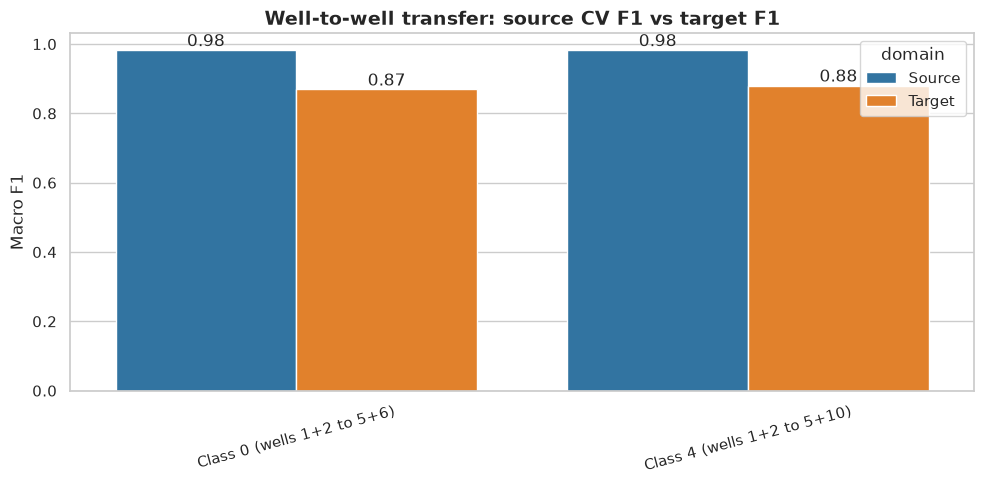

In [15]:
# Figure: well-to-well transfer (source CV F1 vs target F1)
well_rows = pd.DataFrame([
    {'pair': 'Class 0 (wells 1+2 to 5+6)', 'F1_source': f1_src, 'F1_target': f1_tgt},
    {'pair': 'Class 4 (wells 1+2 to 5+10)', 'F1_source': f1_4_src, 'F1_target': f1_4_tgt},
])
well_long = pd.melt(well_rows, id_vars='pair',
                    value_vars=['F1_source', 'F1_target'],
                    var_name='domain', value_name='F1')
well_long['domain'] = well_long['domain'].map(
    {'F1_source': 'Source', 'F1_target': 'Target'})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=well_long, x='pair', y='F1', hue='domain',
            palette=['#1f77b4', '#ff7f0e'], ax=ax)
ax.set_title('Well-to-well transfer: source CV F1 vs target F1',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Macro F1')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
for i, (_, row) in enumerate(well_rows.iterrows()):
    ax.text(i - 0.2, row['F1_source'], f"{row['F1_source']:.2f}",
            ha='center', va='bottom')
    ax.text(i + 0.2, row['F1_target'], f"{row['F1_target']:.2f}",
            ha='center', va='bottom')
plt.tight_layout()
plt.show()

Well variation alone causes a measurable transfer drop within the same event types: **Class 0** loses 0.11 (F1 from 0.98 to 0.87) and **Class 4** loses 0.10 (F1 from 0.98 to 0.88) when moving between well groups. The same fault is not the same distribution across wells, which motivates treating well groups as distinct domains.

## 5. Intra-real splits: Time-period transfer

We will test concept drift by training on older data and testing on newer data from the same well. Class 0 compares well 2 in 2013 vs 2017, class 4 compares well 2 in 2013 vs 2014.

In [16]:
def get_year(inst_id: str) -> int | None:
    """
    Extract the year from an instance ID if it follows the expected format.

    Args:
        inst_id (str): The instance ID string.
    Returns:
        int | None: The extracted year as an integer, or None if the format is invalid.
    """
    parts = inst_id.split('_')
    if len(parts) >= 2 and parts[0].startswith('WELL'):
        ts = parts[-1]
        if len(ts) >= 8 and ts.isdigit(): return int(ts[:4])
    return None

CLS = 0
WID = 'WELL-00002'

inst_by_year = {}
if CLS in data and 'real' in data[CLS]:
    for inst in data[CLS]['real']:
        if get_well_id(inst['id']) == WID:
            y = get_year(inst['id'])
            if y: inst_by_year.setdefault(y, []).append(inst)

print(f'Class 0, {WID}: instances per year')
for y in sorted(inst_by_year):
    print(f'  {y}: {len(inst_by_year[y])}')

time_src = inst_by_year.get(2013, [])
time_tgt = inst_by_year.get(2017, [])
print(f'\nSource (2013): {len(time_src)}, Target (2017): {len(time_tgt)}')

if 4 in data and 'real' in data[4]:
    inst_by_year_4 = {}
    for inst in data[4]['real']:
        if get_well_id(inst['id']) == WID:
            y = get_year(inst['id'])
            if y: inst_by_year_4.setdefault(y, []).append(inst)
    print(f'Class 4, {WID}: instances per year')
    for y in sorted(inst_by_year_4):
        print(f'  {y}: {len(inst_by_year_4[y])}')
    time_src_4 = inst_by_year_4.get(2013, [])
    time_tgt_4 = inst_by_year_4.get(2014, [])
    print(f'\nClass 4 Source (2013): {len(time_src_4)}, Target (2014): {len(time_tgt_4)}')


Class 0, WELL-00002: instances per year
  2013: 8
  2017: 202

Source (2013): 8, Target (2017): 202
Class 4, WELL-00002: instances per year
  2013: 23
  2014: 90

Class 4 Source (2013): 23, Target (2014): 90


In [17]:
# Time-period PAD (class 0)
if len(time_src) >= 3 and len(time_tgt) >= 3:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import SGDClassifier
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import accuracy_score
    
    def extract_features_simple(instances):
        feats = []
        for inst in instances:
            f = []
            for var in VARIABLE_NAMES:
                if var in inst['data'].columns:
                    v = inst['data'][var].dropna().values
                    f += [np.nanmean(v), np.nanstd(v), np.nanpercentile(v, 50)]
                else: f += [np.nan]*3
            feats.append(f)
        return np.array(feats)
    
    X_s = extract_features_simple(time_src)
    X_t = extract_features_simple(time_tgt)
    for X in [X_s, X_t]:
        cm = np.nanmedian(X, axis=0)
        for j in range(X.shape[1]):
            if np.isnan(cm[j]): cm[j] = 0.0
            m = np.isnan(X[:, j])
            if m.any(): X[m, j] = cm[j]
    
    X_all = np.vstack([X_s, X_t])
    y_all = np.array([0]*len(X_s) + [1]*len(X_t))
    clf = Pipeline([('scaler', StandardScaler()),
                    ('sgd', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42))])
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    errs = []
    for tr, te in skf.split(X_all, y_all):
        clf.fit(X_all[tr], y_all[tr])
        errs.append(1 - accuracy_score(y_all[te], clf.predict(X_all[te])))
    me = np.mean(errs)
    pad = max(0, min(1, 2*(1-2*me)))
    print(f'Class 0 time PAD = {pad:.3f}, n_src={len(X_s)}, n_tgt={len(X_t)}')


Class 0 time PAD = 1.000, n_src=8, n_tgt=202


In [18]:
# Time-period TL: train 2013, test 2017 (class 0)
if len(time_src) >= 4 and len(time_tgt) >= 4:
    from sklearn.model_selection import train_test_split
    
    def build_time_data(data, cls, well_id, year_src, year_tgt):
        td = {cls: {}}
        td[cls]['src'] = []
        td[cls]['tgt'] = []
        for inst in data.get(cls, {}).get('real', []):
            if get_well_id(inst['id']) == well_id:
                y = get_year(inst['id'])
                if y == year_src: td[cls]['src'].append(inst)
                if y == year_tgt: td[cls]['tgt'].append(inst)
        return td
    
    td_tl = build_time_data(data, 0, 'WELL-00002', 2013, 2017)
    if len(td_tl[0]['src']) >= 4 and len(td_tl[0]['tgt']) >= 4:
        X_src0, y_src0, _ = extract_features(td_tl, 'src', [0])
        X_tgt0, y_tgt0, _ = extract_features(td_tl, 'tgt', [0])
        if len(np.unique(y_src0)) >= 2 and len(np.unique(y_tgt0)) >= 2:
            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_src0, y_src0)
            f1_s = f1_score(y_src0, rf.predict(X_src0), average='macro')
            f1_t = f1_score(y_tgt0, rf.predict(X_tgt0), average='macro')
            print(f'Class 0 time TL: train F1={f1_s:.3f}, test F1={f1_t:.3f}, drop={f1_s-f1_t:.3f}')


## 6. Key Findings

### Cross-source transfer
- **Simulated to Real**: F1 drops from 0.98 (within-source CV) to 0.07 (target)
- **Hand-drawn to Real**: F1 drops from 0.90 to 0.65 (moderate, and 3.6x better than 939 simulated instances)
- **Per-class**: class 5 (Rapid Productivity Loss) and class 3 (Severe Slugging) have the worst simulated-to-real transfer

### Mixed-source
- **Adding simulated**: neutral at the macro level (F1 -0.001 vs real-only, shared split)
- **Adding hand-drawn**: also neutral (-0.000)
- **Rare classes**: simulated data does not help them either (per-class F1 unchanged, class 5 stays 0.86)
- **Quantity does not compensate for quality** in synthetic data

### Well-to-well transfer
- **Class 0 (Normal)**: measurable drop (F1 from 0.98 to 0.87) across different well groups
- **Class 4 (Flow Instability)**: wells are perfectly separable (PAD = 1.0) for the same fault

### Time-period transfer
- **Class 0 (2013 to 2017)**: PAD = 1.0, clear concept drift over 4 years
- **Drift-prone variables**: P-TPT, P-MON-CKP show complete CDF separation, while QGL shows zero drift
- **Implication**: domain adaptation should focus on the drift-prone sensors


## 7. Correlation between domain distance and transfer performance drop

We will line up the domain distances measured in stage 1 (`3w_dom_dist.ipynb`) with the transfer performance drops measured in this notebook, and discuss whether larger distances predict larger drops. The table pairs each domain gap with its aggregated distances (KS, Wasserstein, CORAL, PAD from the dom_dist summary section) and the corresponding F1 drop from sections 2 and 4.

| Domain pair | KS (mean) | Wasserstein (mean) | CORAL | PAD | F1 drop |
|---|---|---|---|---|---|
| Real to Real (baseline) | 0 | 0 | 0 | 0 | -0.13 |
| Simulated to Real | 0.42 | 1.0 | 0.077 | 1.0 | 0.91 |
| Hand-drawn to Real | 0.78 | 1.4 | 0.109 | 1.0 | 0.25 |
| Wells 1+2 to 5+6 (class 0) | 0.61 | 1.12 | 0.070 | 1.0 | 0.11 |
| Wells 1+2 to 5+10 (class 4) | 0.74 | 1.42 | 0.057 | 1.0 | 0.10 |
| Time, class 0 (2013 to 2017) | 0.70 | 4.69 | n/a | 1.0 | n/a |
| Time, class 4 (2013 to 2014) | 0.36 | 0.71 | 0.029 | 1.0 | n/a |

The Real to Real row is the same-domain baseline; its negative drop means the held-out test F1 (0.74) exceeds the CV baseline (0.61), an artifact of the section-2 protocol rather than a negative penalty.

The KS and Wasserstein means in the well and time rows aggregate the per-variable bar charts of dom_dist sections 9 and 10 (each mean is over the 6-7 of 8 variables that meet the 100-sample threshold; the class 4 well split drops two variables). CORAL is the single-value print of the same sections. CORAL for the class 0 time split is not computed in dom_dist (only KS and Wasserstein), hence n/a. The time F1 drops are n/a for a structural reason: on well 2 each later year holds a single class (2017 only class 0, 2014 only class 4), so the section-5 time TL cell cannot run a classifier transfer.

Reading the pairs by eye, the drop does not grow with the distance:

1. **The closest pair transfers worst**: real vs simulated has the lowest KS, Wasserstein, and CORAL among the source pairs (0.42, 1.0, 0.077) yet the largest drop (0.91). The simulated instances match the real marginals but misrepresent the fault dynamics, so the marginals are closest exactly where the transfer fails most.
2. **The most distant pair transfers moderately**: hand-drawn vs real has the largest KS and CORAL (0.78, 0.109), yet the F1 drops only 0.25, about 3.6x less than the simulated pair. Here a larger distance coincides with a smaller drop.
3. **PAD cannot rank**: every pair is perfectly separable (PAD = 1.0), so the classifier-based distance carries no information about transfer difficulty.
4. **Separability does not imply difficulty within the real domain**: the well pairs are perfectly separable (PAD = 1.0) yet transfer almost intact (drops 0.11 and 0.10), with CORAL (0.070, 0.057) comparable to the simulated-to-real value (0.077) and mean KS as large or larger (0.61 and 0.74 vs 0.42).
5. **Time-period gaps have no transfer side**: PAD = 1.0 for both year splits, and the class 0 gap shows the largest Wasserstein of all pairs (4.69, four variables at complete CDF separation) with KS 0.70, yet no transfer F1 is measurable: on well 2 each later year holds a single class (2017 only class 0, 2014 only class 4), so the section-5 time TL cell is a degenerate single-class case.

**Conclusion**: the transfer drop does not grow with the statistical distance. It depends on the source of the shift: physics simulation (OLGA) degrades transfer despite close marginals, while expert hand-drawn curves and intra-real well differences transfer well. This matches the stage-1 domain distance results and motivates stage 3, where the use of a CVAE generates data at the same distance budget and is the only generator that improves the rare-class F1.